Совпало фильмов из userInput: 15
k= 3, avg_time=5.4675 sec
k= 5, avg_time=7.2931 sec
k= 8, avg_time=9.4086 sec
k=10, avg_time=9.5617 sec
k=12, avg_time=9.9251 sec
k=15, avg_time=9.8825 sec


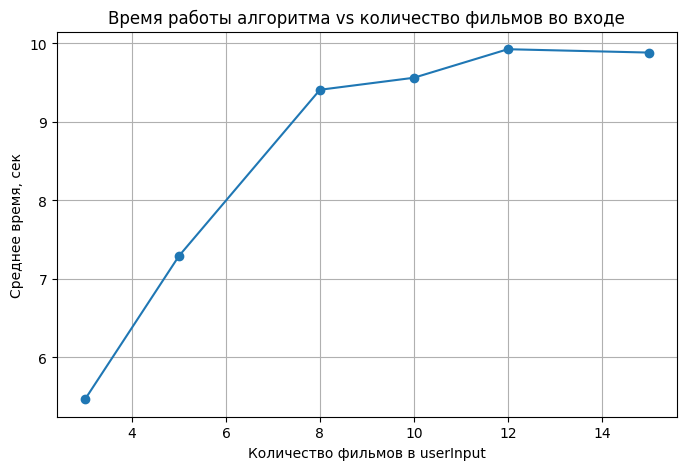

,title,year
0,"Ilsa, She Wolf of the SS",1974
1,"Moderns, The",1988
2,Meshes of the Afternoon,1943
3,Train of Life (Train de vie),1998
4,Blissfully Yours (Sud sanaeha),2002
5,Samurai Rebellion (Jôi-uchi: Hairyô tsuma shim...,1967
6,Experimenter,2015
7,Shoah,1985
8,Johnny Cash at Folsom Prison,2008
9,"Unvanquished, The (Aparajito)",1957


In [7]:
import pandas as pd
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

movies_df = pd.read_csv('/home/jupyter/work/data/movies.csv')
ratings_df = pd.read_csv('/home/jupyter/work/data/ratings.csv')

movies_df.head()

movies_df['year'] = movies_df.title.str.extract('(\(\d\d\d\d\))',expand=False)
movies_df['year'] = movies_df.year.str.extract('(\d\d\d\d)',expand=False)
movies_df['title'] = movies_df.title.str.replace('(\(\d\d\d\d\))', '', regex = True)
movies_df['title'] = movies_df['title'].apply(lambda x: x.strip())

movies_df.head()

movies_df = movies_df.drop(['genres'], axis=1)

movies_df.head()

ratings_df.head()

ratings_df = ratings_df.drop(['timestamp'], axis=1)

ratings_df.head()

userInput = [
    {'title':'BREAKFAST CLUB, THE', 'rating':5},
    {'title':'TOY STORY', 'rating':3.5},
    {'title':'JUMANJI', 'rating':2},
    {'title':'PULP FICTION', 'rating':5},
    {'title':'AKIRA', 'rating':4.5},
    {'title':'MATRIX, THE', 'rating':5},
    {'title':'FIGHT CLUB', 'rating':5},
    {'title':'FORREST GUMP', 'rating':4.5},
    {'title':'INCEPTION', 'rating':5},
    {'title':'GODFATHER, THE', 'rating':5},
    {'title':'DARK KNIGHT, THE', 'rating':5},
    {'title':'SHAWSHANK REDEMPTION, THE', 'rating':5},
    {'title':'GLADIATOR', 'rating':4.5},
    {'title':'INTERSTELLAR', 'rating':5},
    {'title':'SEVEN', 'rating':4.5}
]
inputMovies = pd.DataFrame(userInput)
inputMovies

movies_df['title_upper'] = movies_df['title'].str.upper()
inputMovies['title_upper'] = inputMovies['title'].str.upper()

inputId = movies_df[movies_df['title_upper'].isin(inputMovies['title_upper'].tolist())]
inputMovies = pd.merge(inputId, inputMovies[['title_upper', 'rating']], on='title_upper')
inputMovies = inputMovies.drop(['year'], axis=1)

print(f"Совпало фильмов из userInput: {len(inputMovies)}")
inputMovies.head()

userSubset = ratings_df[ratings_df['movieId'].isin(inputMovies['movieId'].tolist())]
userSubset.head()

userSubsetGroup = userSubset.groupby('userId')
userSubsetGroup.get_group(1130)

userSubsetGroup = sorted(userSubsetGroup,  key=lambda x: len(x[1]), reverse=True)
userSubsetGroup[0:3]

userSubsetGroup = userSubsetGroup[0:100]

pearsonCorrelationDict = {}

for name, group in userSubsetGroup:
    group = group.sort_values(by='movieId')
    inputMovies = inputMovies.sort_values(by='movieId')
    nRatings = len(group)
    temp_df = inputMovies[inputMovies['movieId'].isin(group['movieId'].tolist())]
    tempRatingList = temp_df['rating'].tolist()
    tempGroupList = group['rating'].tolist()
    Sxx = sum([i**2 for i in tempRatingList]) 
    Sxx= Sxx - pow(sum(tempRatingList),2)/float(nRatings)
    Syy = sum([i**2 for i in tempGroupList]) 
    Syy = Syy - pow(sum(tempGroupList),2)/float(nRatings)
    Sxy = sum( i*j for i, j in zip(tempRatingList, tempGroupList)) 
    Sxy = Sxy - sum(tempRatingList)*sum(tempGroupList)/float(nRatings)
    if Sxx != 0 and Syy != 0:
        pearsonCorrelationDict[name] = Sxy/sqrt(Sxx*Syy)
    else:
        pearsonCorrelationDict[name] = 0

pearsonCorrelationDict.items()

pearsonDF = pd.DataFrame.from_dict(pearsonCorrelationDict, orient='index')
pearsonDF.columns = ['similarityIndex']
pearsonDF['userId'] = pearsonDF.index
pearsonDF.index = range(len(pearsonDF))
pearsonDF.head()

topUsers=pearsonDF.sort_values(by='similarityIndex', ascending=False)[0:50]
topUsers.head()

topUsersRating=topUsers.merge(ratings_df, left_on='userId', 
                              right_on='userId', how='inner')
topUsersRating.head()

topUsersRating['weightedRating']=topUsersRating['similarityIndex']*topUsersRating['rating']
topUsersRating.head()

tempTopUsersRating = topUsersRating.groupby('movieId').sum()[['similarityIndex','weightedRating']]
tempTopUsersRating.columns = ['sum_similarityIndex','sum_weightedRating']
tempTopUsersRating.head()

recommendation_df = pd.DataFrame()
recommendation_df['weighted average recommendation score'] = tempTopUsersRating['sum_weightedRating']/tempTopUsersRating['sum_similarityIndex']
recommendation_df['movieId'] = tempTopUsersRating.index
recommendation_df.head()

recommendation_df = recommendation_df.sort_values(by='weighted average recommendation score', ascending=False)
recommendation_df.head(10)

movies_df.loc[movies_df['movieId'].isin(recommendation_df.head(10)['movieId'].tolist())]

def run_recommendation_for_k(k, movies_df, ratings_df, full_input):
    sample_input = full_input.iloc[:k].copy()
    sample_input['title_upper'] = sample_input['title'].str.upper()

    sample_inputId = movies_df[movies_df['title_upper'].isin(sample_input['title_upper'].tolist())]
    sample_movies = pd.merge(sample_inputId, sample_input[['title_upper', 'rating']], on='title_upper')
    sample_movies = sample_movies.drop(['year'], axis=1)

    userSubset = ratings_df[ratings_df['movieId'].isin(sample_movies['movieId'].tolist())]
    userSubsetGroup = userSubset.groupby('userId')
    userSubsetGroup = sorted(userSubsetGroup, key=lambda x: len(x[1]), reverse=True)
    userSubsetGroup = userSubsetGroup[0:100]

    pearsonCorrelationDict = {}

    for name, group in userSubsetGroup:
        group = group.sort_values(by='movieId')
        sample_movies = sample_movies.sort_values(by='movieId')

        nRatings = len(group)
        temp_df = sample_movies[sample_movies['movieId'].isin(group['movieId'].tolist())]
        tempRatingList = temp_df['rating'].tolist()
        tempGroupList = group['rating'].tolist()

        if len(tempRatingList) == 0:
            continue

        Sxx = sum([i**2 for i in tempRatingList])
        Sxx = Sxx - pow(sum(tempRatingList), 2) / float(len(tempRatingList))

        Syy = sum([i**2 for i in tempGroupList])
        Syy = Syy - pow(sum(tempGroupList), 2) / float(len(tempGroupList))

        Sxy = sum(i*j for i, j in zip(tempRatingList, tempGroupList))
        Sxy = Sxy - sum(tempRatingList) * sum(tempGroupList) / float(len(tempRatingList))

        if Sxx != 0 and Syy != 0:
            pearsonCorrelationDict[name] = Sxy / sqrt(Sxx * Syy)
        else:
            pearsonCorrelationDict[name] = 0

    if len(pearsonCorrelationDict) == 0:
        return

    pearsonDF = pd.DataFrame.from_dict(pearsonCorrelationDict, orient='index')
    pearsonDF.columns = ['similarityIndex']
    pearsonDF['userId'] = pearsonDF.index
    pearsonDF.index = range(len(pearsonDF))

    topUsers = pearsonDF.sort_values(by='similarityIndex', ascending=False)[0:50]
    topUsersRating = topUsers.merge(ratings_df, on='userId', how='inner')
    topUsersRating['weightedRating'] = topUsersRating['similarityIndex'] * topUsersRating['rating']

    tempTopUsersRating = topUsersRating.groupby('movieId').sum(numeric_only=True)[['similarityIndex', 'weightedRating']]
    tempTopUsersRating.columns = ['sum_similarityIndex', 'sum_weightedRating']

    recommendation_df = pd.DataFrame()
    recommendation_df['weighted average recommendation score'] = (
        tempTopUsersRating['sum_weightedRating'] / tempTopUsersRating['sum_similarityIndex']
    )
    recommendation_df['movieId'] = tempTopUsersRating.index
    recommendation_df = recommendation_df.sort_values(by='weighted average recommendation score', ascending=False)

sizes = [3, 5, 8, 10, 12, 15]
times = []
full_input = pd.DataFrame(userInput)

for k in sizes:
    repeats = 5
    run_times = []

    for _ in range(repeats):
        t0 = time.perf_counter()
        run_recommendation_for_k(k, movies_df, ratings_df, full_input)
        t1 = time.perf_counter()
        run_times.append(t1 - t0)

    avg_time = np.mean(run_times)
    times.append(avg_time)
    print(f"k={k:2d}, avg_time={avg_time:.4f} sec")

plt.figure(figsize=(8,5))
plt.plot(sizes, times, marker='o')
plt.title('Время работы алгоритма vs количество фильмов во входе')
plt.xlabel('Количество фильмов в userInput')
plt.ylabel('Среднее время, сек')
plt.grid(True)
plt.show()


top10 = recommendation_df.head(10).copy()

if top10.index.name == 'movieId' and 'movieId' in top10.columns:
    top10 = top10.reset_index(drop=True)
elif top10.index.name == 'movieId' and 'movieId' not in top10.columns:
    top10 = top10.reset_index()

top10_with_info = top10.merge(
    movies_df[['movieId', 'title', 'year']],
    on='movieId',
    how='left'
)

display(top10_with_info[['title', 'year']])

top10_with_info = top10.merge(
    movies_df[['movieId', 'title', 'year']],
    on='movieId',
    how='left'
)
